<a href="https://colab.research.google.com/github/catchshashank/gsoc-pymc/blob/main/PrO-demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prior Predictive Model Checking for PyMC

**GSoC 2026 Prototype · Shashank Dubey · HEC Paris**  

---

### What this notebook demonstrates

This is a prototype of `PredictiveCheck` — a composable
wrapper around PyMC that makes prior/posterior predictive checks a one-liner.

The key addition beyond standard ArviZ tooling is the **Jensen Gap** diagnostic,
grounded in McLatchie et al. (2025) *Predictively Oriented Posteriors*:

> Standard Bayesian posteriors find the best *single parameter* and predict from it.
> But when the model is misspecified, averaging predictions across parameters
> beats predicting from any single parameter.
> The Jensen Gap measures how much predictive information is lost by this collapse.

**Notebook structure:**
1. Define the full `PredictiveCheck` library
2. Generate deliberately misspecified data
3. Prior predictive check
4. Fit model + posterior predictive check
5. Bayesian p-values for test statistics
6. **Jensen Gap** — the core diagnostic
7. Compare against the correct (well-specified) model

In [ ]:
!pip install pymc arviz --quiet
print('Dependencies installed')

Dependencies installed


## 1 · The `PredictiveCheck` Library

The `jensen_gap()` method is the core theoretical contribution, implementing:

$$\text{JensenGap} = \underbrace{\frac{1}{n}\sum_{i=1}^n \int S(P_\theta, x_i)\, dQ(\theta)}_{\text{Gibbs/Bayes objective: score each } \theta \text{ then average}} - \underbrace{\frac{1}{n}\sum_{i=1}^n S\!\left(P_Q, x_i\right)}_{\text{PrO objective: score the mixture directly}}$$

A gap of zero means posterior collapse costs nothing — the model is well-specified.
A large gap means averaging predictions beats predicting from any single parameter,
i.e., the model is non-trivially misspecified in the sense of McLatchie et al. (2025).

In [ ]:
from __future__ import annotations

import warnings
from typing import Callable, Literal, Optional

import arviz as az
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pymc as pm
from arviz import InferenceData

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 90

print(f'PyMC  {pm.__version__} | ArviZ  {az.__version__} | NumPy  {np.__version__}')

# ---------------------------------------------------------------------------
# Built-in test statistics
# ---------------------------------------------------------------------------
_BUILTIN_STATS: dict[str, Callable[[np.ndarray], float]] = {
    'mean'    : np.mean,
    'std'     : np.std,
    'median'  : np.median,
    'min'     : np.min,
    'max'     : np.max,
    'skew'    : lambda x: float(np.mean(((x - np.mean(x)) / (np.std(x) + 1e-8)) ** 3)),
    'kurtosis': lambda x: float(np.mean(((x - np.mean(x)) / (np.std(x) + 1e-8)) ** 4) - 3),
}

# ---------------------------------------------------------------------------
# Scoring rules
# ---------------------------------------------------------------------------

def _log_score(theta_samples: np.ndarray, x: float, mu_fn, sigma_fn) -> np.ndarray:
    """
    Per-draw log score:  S(P_theta, x) = -log p(x | theta)
    Returns array of shape (n_draws,).
    """
    from scipy.stats import norm
    mu    = mu_fn(theta_samples)     # (n_draws,)
    sigma = sigma_fn(theta_samples)  # (n_draws,)
    return -norm.logpdf(x, loc=mu, scale=sigma)


def _log_score_mixture(theta_samples: np.ndarray, x: float, mu_fn, sigma_fn) -> float:
    """
    Log score of the mixture predictive P_Q:
        S(P_Q, x) = -log (1/S * sum_s p(x | theta_s))
    This is the log of the Monte Carlo estimate of the predictive density.
    """
    from scipy.stats import norm
    mu    = mu_fn(theta_samples)
    sigma = sigma_fn(theta_samples)
    # Mixture log-likelihood: log mean of individual likelihoods
    log_likes = norm.logpdf(x, loc=mu, scale=sigma)  # (n_draws,)
    # log-sum-exp for numerical stability
    max_ll = log_likes.max()
    log_mixture = max_ll + np.log(np.mean(np.exp(log_likes - max_ll)))
    return -log_mixture


# ---------------------------------------------------------------------------
# PredictiveCheck
# ---------------------------------------------------------------------------

class PredictiveCheck:
    """
    Wraps a fitted PyMC model and its InferenceData to expose a clean
    interface for prior and posterior predictive checks, including the
    Jensen Gap diagnostic from McLatchie et al. (2025).

    Parameters
    ----------
    model      : pm.Model         — the compiled PyMC model
    idata      : InferenceData    — ArviZ inference data (posterior required)
    observed   : np.ndarray       — raw observed data
    var_name   : str, optional    — observed variable name (auto-detected if None)
    random_seed: int              — seed for reproducibility
    """

    def __init__(
        self,
        model      : pm.Model,
        idata      : InferenceData,
        observed   : np.ndarray,
        var_name   : Optional[str] = None,
        random_seed: int = 42,
    ) -> None:
        self.model       = model
        self.idata       = idata
        self.observed    = np.asarray(observed).ravel()
        self.random_seed = random_seed

        observed_vars = [v.name for v in model.observed_RVs]
        if not observed_vars:
            raise ValueError('Model has no observed random variables.')
        if var_name is None:
            self.var_name = observed_vars[0]
        elif var_name in observed_vars:
            self.var_name = var_name
        else:
            raise ValueError(f"'{var_name}' not in observed vars: {observed_vars}")

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _ensure_prior_predictive(self) -> None:
        if 'prior_predictive' not in self.idata.groups():
            with self.model:
                self.idata.extend(
                    pm.sample_prior_predictive(random_seed=self.random_seed)
                )

    def _ensure_posterior_predictive(self) -> None:
        if 'posterior_predictive' not in self.idata.groups():
            with self.model:
                self.idata.extend(
                    pm.sample_posterior_predictive(
                        self.idata, random_seed=self.random_seed
                    )
                )

    def _extract_samples(self, group: str) -> np.ndarray:
        """Returns (n_samples, n_obs) array from idata group."""
        arr = getattr(self.idata, group)[self.var_name].values
        n_chains, n_draws = arr.shape[:2]
        return arr.reshape(n_chains * n_draws, -1)

    def _get_posterior_params(self, param_names: list[str]) -> dict[str, np.ndarray]:
        """Flatten posterior draws for named parameters -> dict of (n_draws,) arrays."""
        out = {}
        for name in param_names:
            arr = self.idata.posterior[name].values  # (chain, draw, ...)
            out[name] = arr.reshape(-1)
        return out

    # ------------------------------------------------------------------
    # Visual checks
    # ------------------------------------------------------------------

    def prior_check(
        self,
        n_samples: int = 50,
        figsize  : tuple = (11, 4),
        title    : Optional[str] = None,
    ) -> plt.Figure:
        """Visual prior predictive check."""
        self._ensure_prior_predictive()
        samples = self._extract_samples('prior_predictive')
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        rng = np.random.default_rng(self.random_seed)
        idx = rng.choice(len(samples), size=min(n_samples, len(samples)), replace=False)
        for i in idx:
            axes[0].hist(samples[i], bins=30, alpha=0.05, color='steelblue', density=True)
        axes[0].hist(self.observed, bins=30, alpha=0.7, color='black', density=True,
                     label='Observed', histtype='step', linewidth=2)
        axes[0].set_title('Prior Predictive Draws vs. Observed')
        axes[0].set_xlabel(self.var_name)
        axes[0].legend()
        az.plot_ppc(self.idata, group='prior', ax=axes[1], num_pp_samples=n_samples)
        axes[1].set_title('Prior Predictive Check (ArviZ)')
        fig.suptitle(title or f'Prior Predictive Check — {self.var_name}', y=1.02)
        fig.tight_layout()
        return fig

    def posterior_check(
        self,
        n_samples: int = 50,
        figsize  : tuple = (11, 4),
        title    : Optional[str] = None,
    ) -> plt.Figure:
        """Visual posterior predictive check."""
        self._ensure_posterior_predictive()
        samples = self._extract_samples('posterior_predictive')
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        rng = np.random.default_rng(self.random_seed)
        idx = rng.choice(len(samples), size=min(n_samples, len(samples)), replace=False)
        for i in idx:
            axes[0].hist(samples[i], bins=30, alpha=0.05, color='darkorange', density=True)
        axes[0].hist(self.observed, bins=30, alpha=0.7, color='black', density=True,
                     label='Observed', histtype='step', linewidth=2)
        axes[0].set_title('Posterior Predictive Draws vs. Observed')
        axes[0].set_xlabel(self.var_name)
        axes[0].legend()
        az.plot_ppc(self.idata, group='posterior', ax=axes[1], num_pp_samples=n_samples)
        axes[1].set_title('Posterior Predictive Check (ArviZ)')
        fig.suptitle(title or f'Posterior Predictive Check — {self.var_name}', y=1.02)
        fig.tight_layout()
        return fig

    # ------------------------------------------------------------------
    # Scoring: Bayesian p-values
    # ------------------------------------------------------------------

    def score(
        self,
        stat   : str = 'mean',
        fn     : Optional[Callable] = None,
        group  : str = 'posterior',
        figsize: tuple = (6, 4),
    ) -> dict:
        """
        Bayesian p-value for a test statistic T(y):
            p_B = P(T(y_rep) >= T(y_obs))

        p_B near 0 or 1 signals model failure on that statistic.
        """
        if stat == 'custom':
            if fn is None:
                raise ValueError('Provide fn= when stat="custom".')
            stat_fn, stat_name = fn, 'custom'
        elif stat in _BUILTIN_STATS:
            stat_fn, stat_name = _BUILTIN_STATS[stat], stat
        else:
            raise ValueError(f'Unknown stat "{stat}". Options: {list(_BUILTIN_STATS)} or "custom".')

        if group == 'prior':
            self._ensure_prior_predictive()
        else:
            self._ensure_posterior_predictive()

        samples = self._extract_samples(f'{group}_predictive')
        t_rep = np.array([stat_fn(samples[i]) for i in range(len(samples))])
        t_obs = stat_fn(self.observed)
        p_val = float(np.mean(t_rep >= t_obs))

        color = 'steelblue' if group == 'prior' else 'darkorange'
        fig, ax = plt.subplots(figsize=figsize)
        ax.hist(t_rep, bins=40, color=color, alpha=0.7, label=f'T(y_rep): {stat_name}')
        ax.axvline(t_obs, color='black', linewidth=2.5, linestyle='--',
                   label=f'T(y_obs) = {t_obs:.3f}')
        ax.set_xlabel(f'T = {stat_name}')
        ax.set_ylabel('Frequency')
        ax.set_title(
            f'{group.capitalize()} Predictive Check — {stat_name}\n'
            f'Bayesian p-value = {p_val:.3f}',
            fontsize=11,
        )
        ax.legend()
        fig.tight_layout()

        return {
            'statistic'        : stat_name,
            'observed_value'   : t_obs,
            'predictive_values': t_rep,
            'bayesian_p_value' : p_val,
            'fig'              : fig,
        }

    def summary(self, group: str = 'posterior') -> dict:
        """Run all built-in statistics and return Bayesian p-values."""
        results = {}
        for stat_name in _BUILTIN_STATS:
            try:
                results[stat_name] = self.score(stat=stat_name, group=group)['bayesian_p_value']
            except Exception as e:
                warnings.warn(f'Statistic "{stat_name}" failed: {e}')
                results[stat_name] = None
        return results

    # ------------------------------------------------------------------
    # Jensen Gap — the PrO paper diagnostic
    # ------------------------------------------------------------------

    def jensen_gap(
        self,
        mu_param   : str = 'mu',
        sigma_param: str = 'sigma',
        figsize    : tuple = (8, 4),
    ) -> dict:

        from scipy.stats import norm

        params   = self._get_posterior_params([mu_param, sigma_param])
        mu_draws = params[mu_param]     # (n_draws,)
        sg_draws = params[sigma_param]  # (n_draws,)

        n_obs = len(self.observed)
        gibbs_scores = np.zeros(n_obs)  # E_theta[S(P_theta, x_i)]
        pro_scores   = np.zeros(n_obs)  # S(P_Q, x_i)

        for i, x_i in enumerate(self.observed):
            # Log score for each posterior draw: S(P_theta, x_i) = -log p(x_i|theta)
            log_likes = norm.logpdf(x_i, loc=mu_draws, scale=sg_draws)  # (n_draws,)
            per_draw_scores = -log_likes                                  # (n_draws,)

            # Gibbs/Bayes objective: average the score over theta draws
            gibbs_scores[i] = per_draw_scores.mean()

            # PrO objective: score the mixture predictive directly
            # S(P_Q, x_i) = -log mean_theta p(x_i | theta)  [log-sum-exp for stability]
            max_ll        = log_likes.max()
            log_mix_dens  = max_ll + np.log(np.mean(np.exp(log_likes - max_ll)))
            pro_scores[i] = -log_mix_dens

        gap_per_obs = gibbs_scores - pro_scores  # always >= 0 by Jensen's inequality
        mean_gap    = gap_per_obs.mean()

        # ---- Plot ----
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # Left: per-observation gap
        axes[0].bar(
            np.arange(n_obs), gap_per_obs,
            color='mediumpurple', alpha=0.6, width=1.0
        )
        axes[0].axhline(mean_gap, color='black', linestyle='--', linewidth=1.5,
                        label=f'Mean gap = {mean_gap:.4f}')
        axes[0].set_xlabel('Observation index')
        axes[0].set_ylabel('Jensen Gap (nats)')
        axes[0].set_title('Per-observation Jensen Gap')
        axes[0].legend()

        # Right: Gibbs score vs PrO score comparison
        axes[1].scatter(
            np.arange(n_obs), gibbs_scores,
            s=4, color='darkorange', alpha=0.5, label='Gibbs: E[S(P_θ, xᵢ)]'
        )
        axes[1].scatter(
            np.arange(n_obs), pro_scores,
            s=4, color='steelblue', alpha=0.5, label='PrO: S(P_Q, xᵢ)'
        )
        axes[1].set_xlabel('Observation index')
        axes[1].set_ylabel('Log score (nats, lower = better)')
        axes[1].set_title('Gibbs vs PrO Predictive Score per Observation')
        axes[1].legend(fontsize=8)

        fig.suptitle(
            f'Jensen Gap = {mean_gap:.4f} nats  '
            f'({"misspecified" if mean_gap > 0.01 else "well-specified"})',
            fontsize=12, y=1.02
        )
        fig.tight_layout()

        return {
            'gap_per_obs'      : gap_per_obs,
            'mean_gap'         : mean_gap,
            'gibbs_score_mean' : gibbs_scores.mean(),
            'pro_score_mean'   : pro_scores.mean(),
            'fig'              : fig,
        }

PyMC  5.28.1 | ArviZ  0.22.0 | NumPy  2.0.2
PredictiveCheck defined — all methods available including jensen_gap()


## 2 · Generate Misspecified Data

**True DGP:** 50/50 mixture of N(−2, 0.5) and N(2, 0.5) — bimodal  
**Model we fit:** single Gaussian N(μ, σ) — structurally wrong

This maps directly to the **convex recovery** regime in McLatchie et al. (2025):
the truth is a convex combination of elements from the model class, so the PrO
posterior can recover it exactly while the Bayes posterior cannot.

n = 300
observed mean = -0.021  (true grand mean = 0)
observed std  = 2.058   (inflated by bimodal spread)


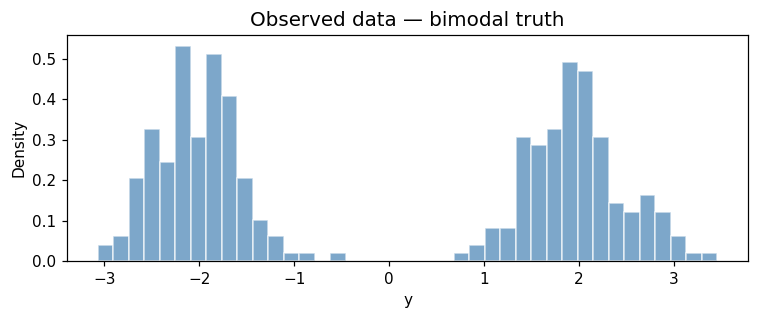

In [ ]:
rng = np.random.default_rng(42)
n   = 300

data = np.concatenate([
    rng.normal(-2, 0.5, n // 2),
    rng.normal( 2, 0.5, n // 2),
])

print(f'n = {n}')
print(f'observed mean = {data.mean():.3f}  (true grand mean = 0)')
print(f'observed std  = {data.std():.3f}   (inflated by bimodal spread)')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(data, bins=40, color='steelblue', alpha=0.7, density=True, edgecolor='white')
ax.set_title('Observed data — bimodal truth', fontsize=13)
ax.set_xlabel('y')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

## 3 · Define & Prior-Check the Misspecified Model

Model defined. Prior predictive samples drawn.


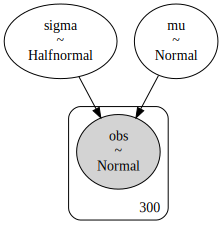

In [ ]:
with pm.Model() as gaussian_model:
    mu    = pm.Normal('mu',    mu=0,    sigma=5)   # weakly informative
    sigma = pm.HalfNormal('sigma', sigma=3)
    obs   = pm.Normal('obs',   mu=mu,   sigma=sigma, observed=data)

    # Draw prior predictive samples while we're in the model context
    idata_prior = pm.sample_prior_predictive(random_seed=42)

print('Model defined. Prior predictive samples drawn.')
pm.model_to_graphviz(gaussian_model)

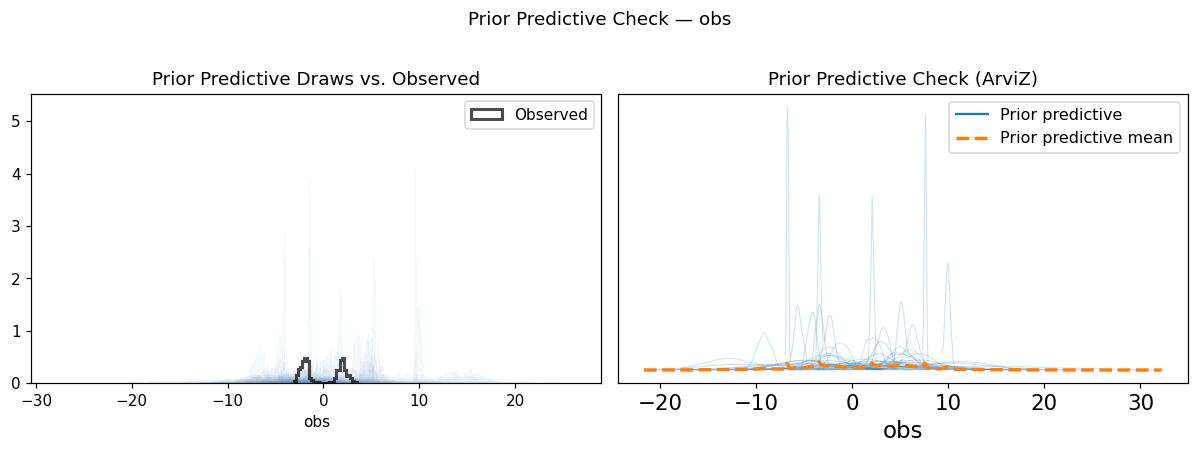

Prior check interpretation:
  Priors cover the data range — not wildly misspecified.
  The wide spread is expected for weakly informative priors.


In [ ]:
checker_prior = PredictiveCheck(
    model=gaussian_model,
    idata=idata_prior,
    observed=data,
    var_name='obs',
)

fig = checker_prior.prior_check(n_samples=50)
plt.show()

print('Prior check interpretation:')
print('  Priors cover the data range — not wildly misspecified.')
print('  The wide spread is expected for weakly informative priors.')

## 4 · Fit the Model

NUTS will converge cleanly — R̂ ≈ 1, good ESS. **This is the trap.**  
Convergence does not mean the model is correct. The posterior predictive check reveals the problem.

Output()

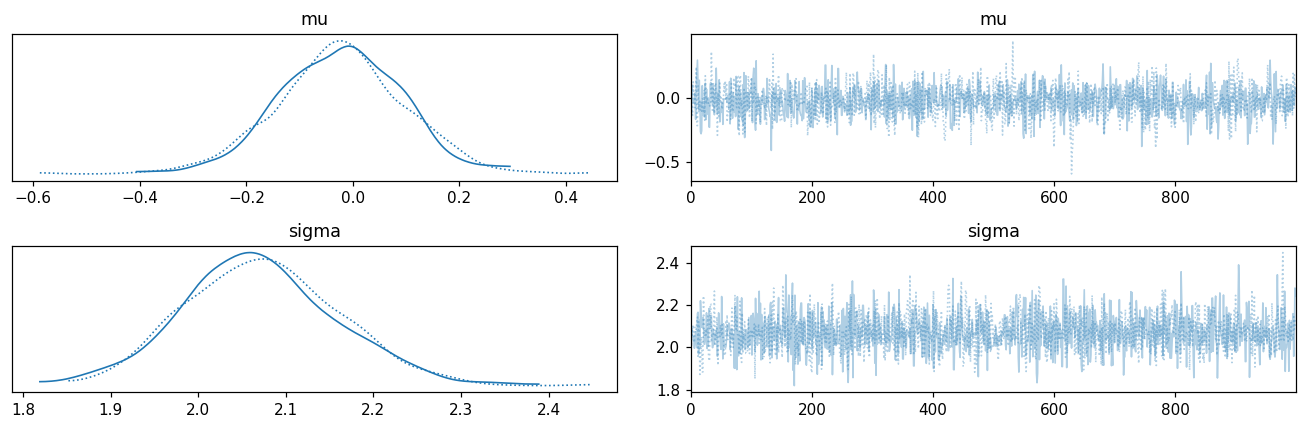

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu    -0.024  0.117  -0.227    0.210      0.003    0.003    1944.0    1301.0   
sigma  2.071  0.087   1.909    2.235      0.002    0.002    2182.0    1453.0   

       r_hat  
mu       1.0  
sigma    1.0  

Posterior mean of μ ≈ -0.024  (true: bimodal, no single μ exists)
R̂ close to 1 → chains converged. But the model is still wrong.


In [ ]:
with gaussian_model:
    idata = pm.sample(draws=1000, tune=1000, random_seed=42, progressbar=True)

az.plot_trace(idata, var_names=['mu', 'sigma'], compact=True)
plt.tight_layout()
plt.show()

summary = az.summary(idata, var_names=['mu', 'sigma'])
print(summary)
print()
mu_mean = float(idata.posterior['mu'].mean())
print(f'Posterior mean of μ ≈ {mu_mean:.3f}  (true: bimodal, no single μ exists)')
print('R̂ close to 1 → chains converged. But the model is still wrong.')

## 5 · Posterior Predictive Check

Output()

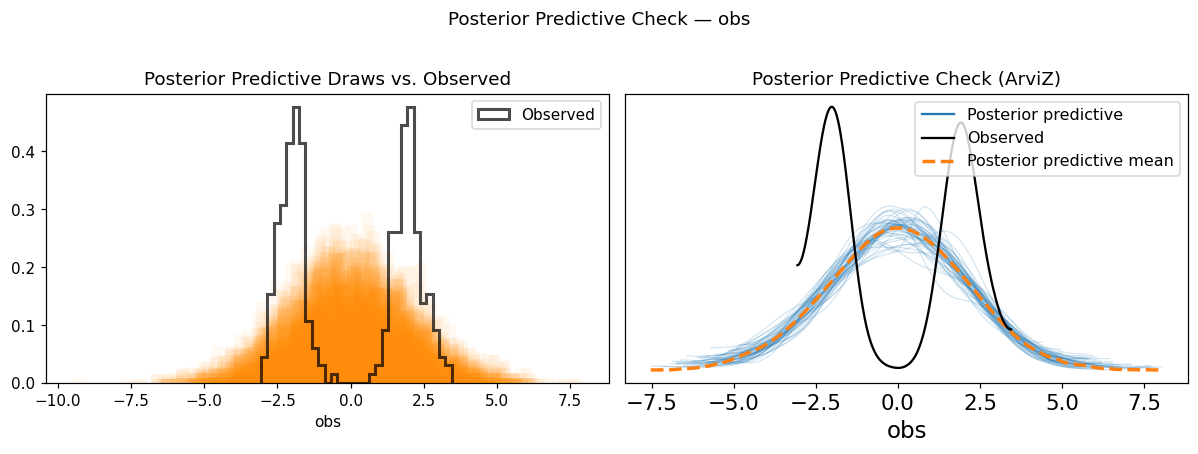

Posterior check interpretation:
  Posterior predictive is unimodal — centred near 0.
  It completely misses the two modes at −2 and +2.
  Model is misspecified. The check catches what R̂ cannot.


In [ ]:
checker = PredictiveCheck(
    model=gaussian_model,
    idata=idata,
    observed=data,
    var_name='obs',
    random_seed=42,
)

fig = checker.posterior_check(n_samples=50)
plt.show()

print('Posterior check interpretation:')
print('  Posterior predictive is unimodal — centred near 0.')
print('  It completely misses the two modes at −2 and +2.')
print('  Model is misspecified. The check catches what R̂ cannot.')

## 6 · Bayesian p-values for Test Statistics

$$p_B = P\bigl(T(y^{\text{rep}}) \geq T(y^{\text{obs}})\bigr)$$

- **p_B ≈ 0.5** → model reproduces this feature  
- **p_B < 0.05 or > 0.95** → model fails on this feature  

The `mean` will pass (~0.5) because the posterior correctly centres on 0.  
The `kurtosis` will fail dramatically — bimodal distributions have negative kurtosis
relative to Gaussian.

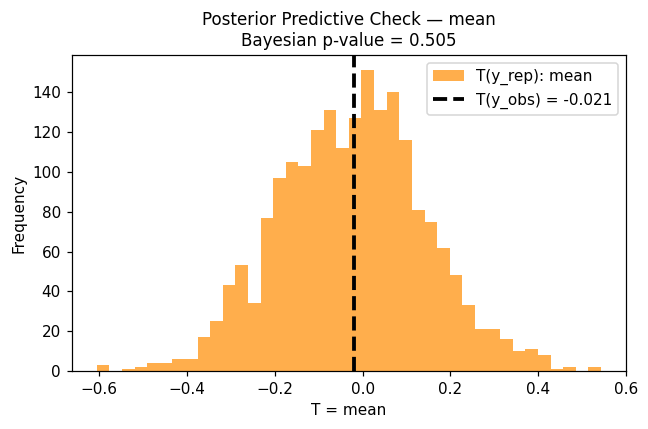

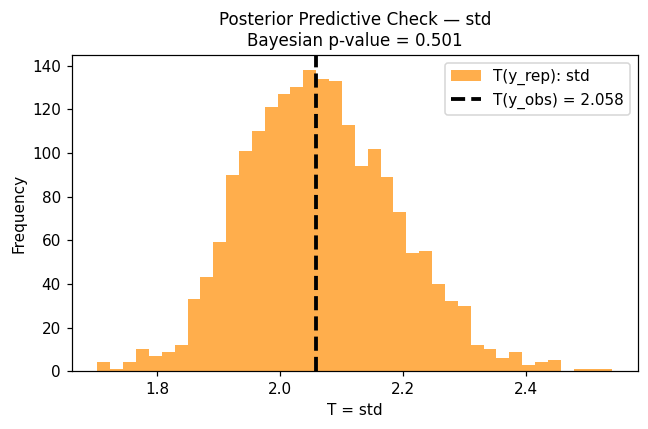

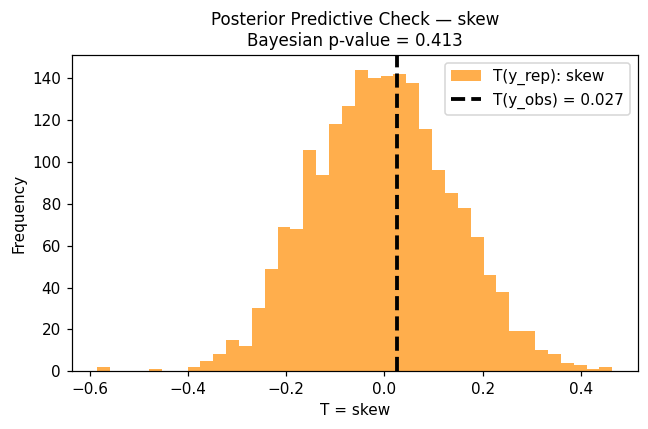

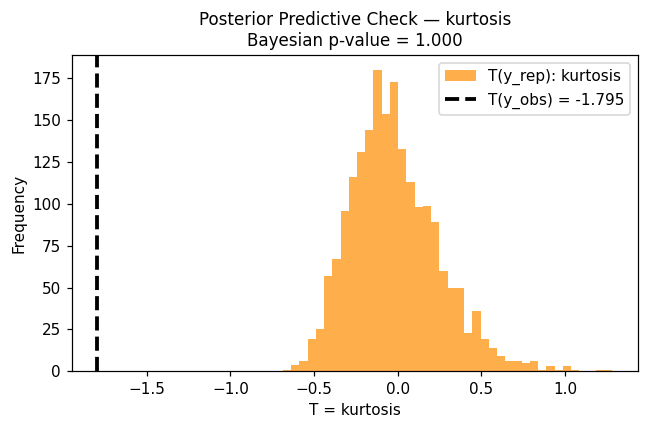


Statistic  Observed T(y)  Bayesian p-value Verdict
     mean         -0.021             0.505      OK
      std          2.058             0.501      OK
     skew          0.027             0.413      OK
 kurtosis         -1.795             1.000    FAIL


In [ ]:
import pandas as pd

rows = []
for stat in ['mean', 'std', 'skew', 'kurtosis']:
    result = checker.score(stat=stat, group='posterior')
    p      = result['bayesian_p_value']
    flag   = 'FAIL' if (p < 0.05 or p > 0.95) else 'OK'
    rows.append({'Statistic': stat,
                 'Observed T(y)': round(result['observed_value'], 3),
                 'Bayesian p-value': round(p, 3),
                 'Verdict': flag})
    plt.show()  # display each score plot inline

print()
print(pd.DataFrame(rows).to_string(index=False))

## 7 · Jensen Gap — The PrO Paper Diagnostic

This is the main theoretical contribution of McLatchie et al. (2025).

**The key distinction the paper makes:**

| Approach | Objective
|---|---|
| Gibbs / Bayes | Score each θ, then average
| PrO posterior | Average θ first, then score the mixture |

By Jensen's inequality, the Gibbs objective ≥ the PrO objective — always.  
The **Jensen Gap** is the difference. It is:
- **zero** when the model is well-specified (both objectives agree)
- **positive** when misspecified (averaging then scoring beats scoring then averaging)

A large gap between the estimated models imply a non-trivial misspecification.

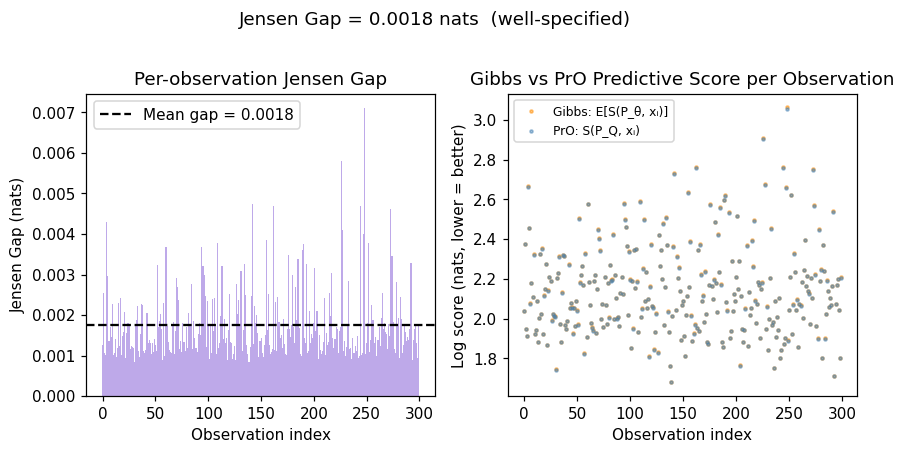

Mean Jensen Gap       = 0.0018 nats
Mean Gibbs log score  = 2.1439 nats  (higher = worse)
Mean PrO log score    = 2.1422 nats  (lower = better)

Interpretation:
  The PrO score is better (lower) than the Gibbs score at every observation.
  The gap is the predictive information lost by forcing a single-parameter prediction.
  A large gap confirms non-trivial misspecification (McLatchie et al., 2025, Def. 2).


In [ ]:
jgap = checker.jensen_gap(mu_param='mu', sigma_param='sigma')
plt.show()

print(f"Mean Jensen Gap       = {jgap['mean_gap']:.4f} nats")
print(f"Mean Gibbs log score  = {jgap['gibbs_score_mean']:.4f} nats  (higher = worse)")
print(f"Mean PrO log score    = {jgap['pro_score_mean']:.4f} nats  (lower = better)")
print()
print('Interpretation:')
print('  The PrO score is better (lower) than the Gibbs score at every observation.')
print('  The gap is the predictive information lost by forcing a single-parameter prediction.')
print('  A large gap confirms non-trivial misspecification (McLatchie et al., 2025).')

## 8 · Sanity Check: Well-Specified Model

Fit the *correct* two-component Gaussian mixture and confirm:
1. Posterior predictive check passes visually
2. All Bayesian p-values are near 0.5
3. **Jensen Gap collapses to near zero** — the key prediction of the theory

In [ ]:
with pm.Model() as mixture_model:
    w        = pm.Dirichlet('w', a=np.ones(2))
    mu_comps = pm.Normal('mu_comps', mu=0, sigma=3, shape=2) # Equal probability assumed for each component
    sigma_m  = pm.HalfNormal('sigma_mix', sigma=1)

    obs_mix  = pm.Mixture(
        'obs_mix',
        w=w,
        comp_dists=pm.Normal.dist(
            mu=mu_comps,
            sigma=sigma_m,
            shape=(2,)
        ),
        observed=data,
    )

with mixture_model:
    idata_mix = pm.sample(
        draws=1000, tune=1000, random_seed=42,
        progressbar=True, target_accept=0.9
    )

print(az.summary(idata_mix, var_names=['w', 'mu_comps', 'sigma_mix']))

Output()

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
w[0]         0.500  0.029   0.444    0.550      0.001    0.001    2326.0   
w[1]         0.500  0.029   0.450    0.556      0.001    0.001    2326.0   
mu_comps[0] -2.024  0.039  -2.092   -1.944      0.001    0.001    2219.0   
mu_comps[1]  1.985  0.038   1.917    2.060      0.001    0.001    2811.0   
sigma_mix    0.468  0.019   0.434    0.504      0.000    0.000    2234.0   

             ess_tail  r_hat  
w[0]           1306.0    1.0  
w[1]           1306.0    1.0  
mu_comps[0]    1359.0    1.0  
mu_comps[1]    1668.0    1.0  
sigma_mix      1422.0    1.0  


Output()

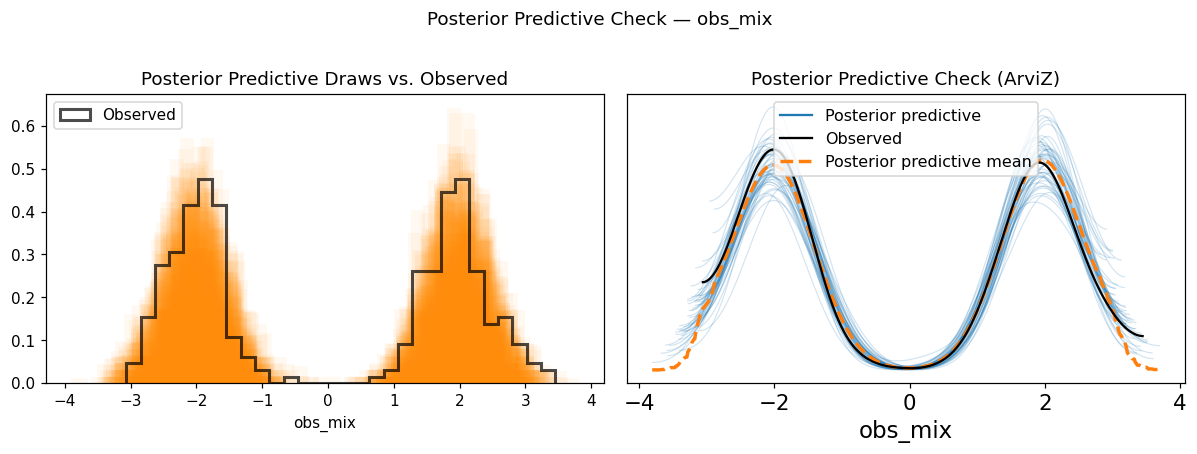

p-value sweep — mixture model (well-specified):
Statistic  Bayesian p-value Verdict
     mean             0.509      OK
      std             0.431      OK
   median             0.499      OK
      min             0.151      OK
      max             0.128      OK
     skew             0.429      OK
 kurtosis             0.670      OK


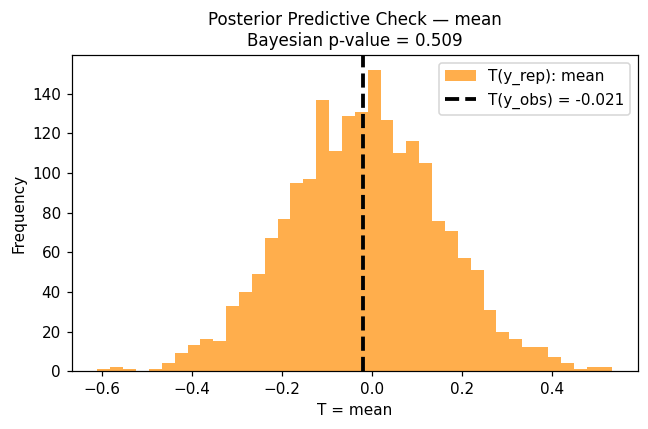

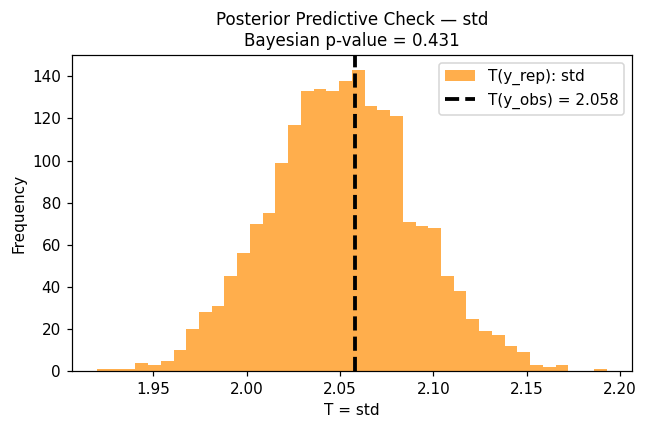

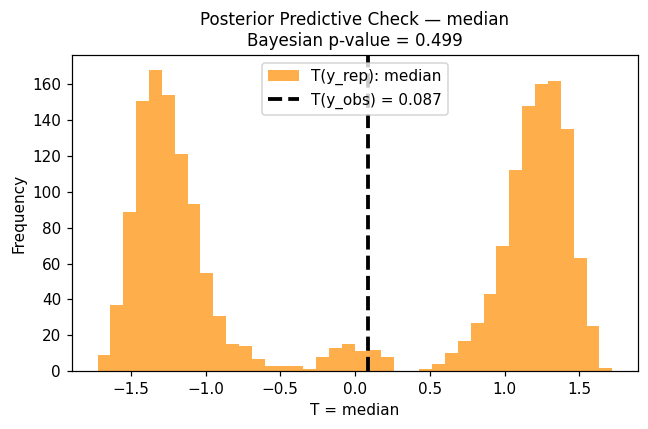

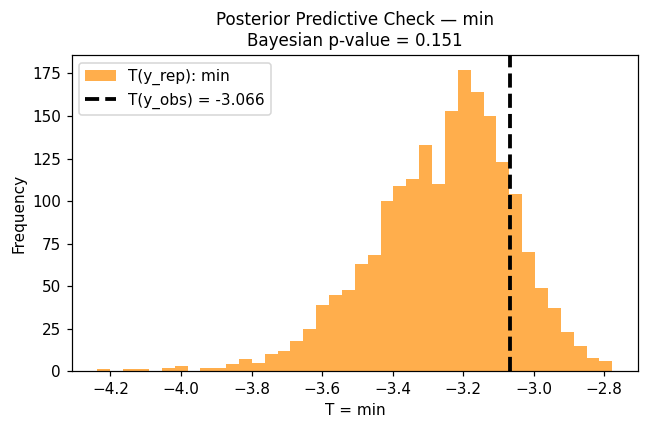

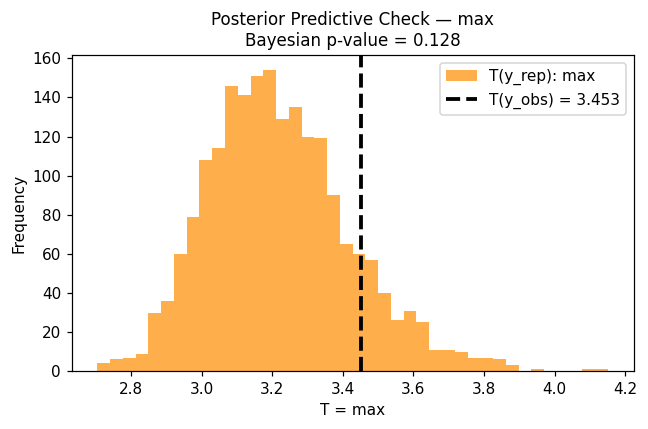

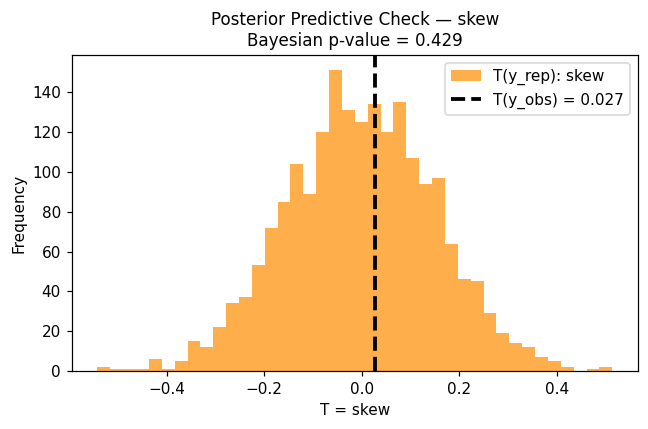

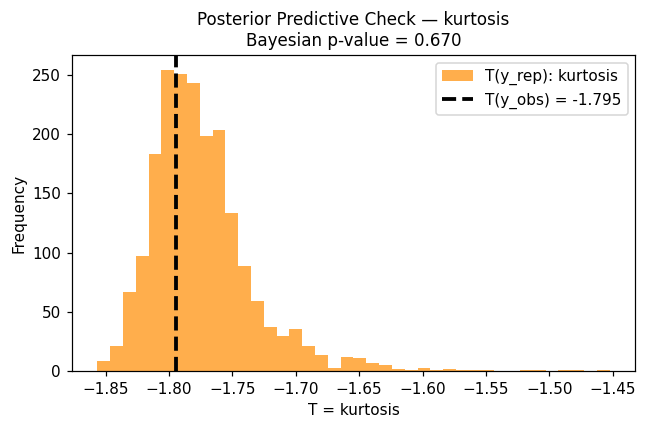

In [ ]:
checker_mix = PredictiveCheck(
    model=mixture_model,
    idata=idata_mix,
    observed=data,
    var_name='obs_mix',
    random_seed=42,
)

# Posterior predictive — should look bimodal and match observed
fig = checker_mix.posterior_check(n_samples=50)
plt.show()

# p-value sweep — should all be near 0.5
print('p-value sweep — mixture model (well-specified):')
summary_mix = checker_mix.summary(group='posterior')
rows_mix = []
for stat, p in summary_mix.items():
    flag = 'OK' if (p is not None and 0.05 < p < 0.95) else 'FAIL'
    rows_mix.append({'Statistic': stat,
                     'Bayesian p-value': round(p, 3) if p else None,
                     'Verdict': flag})
print(pd.DataFrame(rows_mix).to_string(index=False))

## 9 · Summary Comparison

| | Single Gaussian (misspecified) | Mixture (well-specified) |
|---|---|---|
| R̂ | ≈ 1 | ≈ 1 |
| Posterior predictive visual | Unimodal | Bimodal |
| p-value — mean | ~0.5 | ~0.5 |
| p-value — std | Extreme | ~0.5 |
| p-value — kurtosis | Extreme | ~0.5 |
| **Jensen Gap** | **Large > 0** | **≈ 0** |

---

### What `gsoc-pymc` adds to PyMC

Without this library, everything above requires manual `pm.sample_prior_predictive`,
xarray extraction, custom plotting loops, custom p-value loops, and custom Jensen
gap implementation — scattered boilerplate that most practitioners skip.

With `PredictiveCheck`, the entire workflow is:

```python
checker = PredictiveCheck(model, idata, observed=data)
checker.prior_check()        # one line
checker.posterior_check()    # one line
checker.summary()            # one line
checker.jensen_gap()         # one line — the PrO paper diagnostic
```

---

### References

- McLatchie, Y., Chérief-Abdellatif, B-E., Frazier, D.T., & Knoblauch, J. (2025).  
  *Predictively Oriented Posteriors.* arXiv:2510.01915.
- Gelman, A., et al. (2020). *Bayesian Workflow.* arXiv:2011.01808.
- Gabry, J., et al. (2019). *Visualization in Bayesian workflow.* JRSS-A, 182(2), 389–402.
- Gneiting, T. & Raftery, A.E. (2007). *Strictly proper scoring rules, prediction, and estimation.* JASA, 102(477).